In [24]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification, make_moons
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [203]:
X, y = make_classification( n_samples=2502, 
                            random_state=259202,
                            n_features=2, 
                            n_informative=2, 
                            n_redundant=0, 
                            n_repeated=0, 
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202)

In [204]:
X.shape, y.shape, Xm.shape, ym.shape

((2502, 2), (2502,), (2502, 2), (2502,))

In [205]:
def plot_data(X, y, title=""):
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

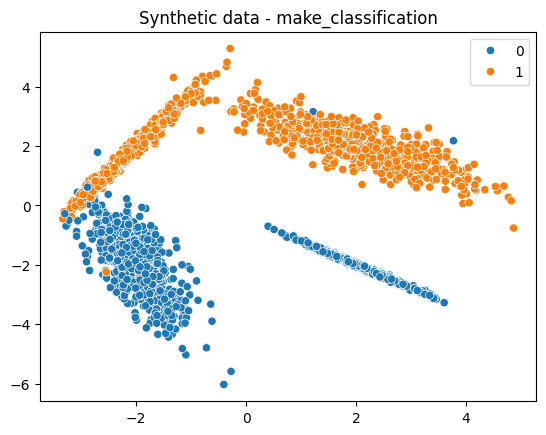

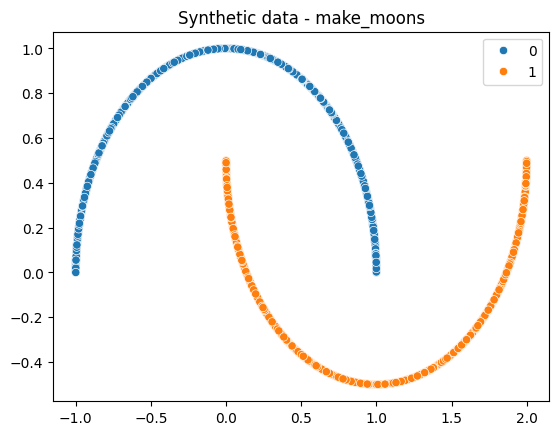

In [206]:
plot_data(X, y, "Synthetic data - make_classification")
plot_data(Xm, ym, "Synthetic data - make_moons")

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)

In [260]:
def plot_decision_boundary(X, y, w, b, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = b + w[0] * xx + w[1] * yy
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z > 0, alpha=0.3)
        
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show() 

In [208]:
def plot_decision_boundary_clf(X, y, clf, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z > 0, alpha=0.3)
        
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show() 

# Implementation of linear SVM

In [209]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_moons = StandardScaler()
Xm_train_scaled = scaler_moons.fit_transform(Xm_train)
Xm_test_scaled = scaler_moons.transform(Xm_test)

In [246]:
y_train_scaled = np.where(y_train == 1, 1, -1)
ym_train_scaled = np.where(ym_train == 1, 1, -1)
y_train_scaled, ym_train_scaled

(array([ 1,  1, -1, ...,  1, -1,  1]), array([ 1, -1,  1, ...,  1, -1, -1]))

In [247]:
X_train_scaled.shape, y_train_scaled.shape

((1876, 2), (1876,))

In [248]:
K = X_train_scaled @ X_train_scaled.T
Y = y_train_scaled.reshape(-1, 1) @ y_train_scaled.reshape(-1, 1).T
K.shape, Y.shape

((1876, 1876), (1876, 1876))

In [ ]:
n = X_train_scaled.shape[0]
YK = Y * K 

def obj(lam):
    # dual: L(lam) = sum(lam) − 0.5 * lam @ (Y*K) lam
    return -(lam.sum() - 0.5 * lam @ YK @ lam)

cons = {'type': 'eq', 'fun': lambda lam: lam @ y_train_scaled} # ensure sum(lam_i * y_i) = 0
bounds = [(0, None)] * n 

# initial guess
lam0 = np.ones(n)

res = minimize(obj,
               x0=lam0,
               bounds=bounds,
               constraints=cons,
               options={'maxiter':5, 'disp':True})

Iteration limit reached    (Exit mode 9)
            Current function value: -68036.45416388262
            Iterations: 5
            Function evaluations: 9389
            Gradient evaluations: 5


In [ ]:
lams = res.x

# support vectors mask
sv = lams > 1e-6

w = (lams * y_train_scaled) @ X_train_scaled
b = np.mean(y_train_scaled[sv] - X_train_scaled[sv] @ w)

def predict(X): 
    return np.sign(X @ w + b) # -1 or 1

def predict_proba(X): 
    return (X @ w + b) # probability

y_test_scaled = np.where(y_test==1, 1, -1)
y_pred = predict(X_test_scaled)

accuracy_impl = accuracy_score(y_test_scaled, y_pred)
print(f"Implemented SVM accuracy: {accuracy_impl}")

Implemented SVM accuracy: 0.9840255591054313


In [254]:
def train_impl_svm(X_train, y_train, maxiter=5):

    y = np.where(y_train == 1, 1, -1)
    n = X_train.shape[0]
    K = X_train @ X_train.T
    Y = y.reshape(-1,1) @ y.reshape(1,-1)
    YK = Y * K

    def obj(lam):
        # dual objective (negated for minimizer)
        return -(lam.sum() - 0.5 * lam @ YK @ lam)

    cons = {'type':'eq', 'fun': lambda lam: lam @ y}
    bounds = [(0, None)] * n
    lam0 = np.ones(n)

    res = minimize(obj,
                   x0=lam0,
                   bounds=bounds,
                   constraints=cons,
                   options={'maxiter': maxiter, 'disp': False})
    lams = res.x
    sv_mask = lams > 1e-6

    w = (lams * y) @ X_train
    b = np.mean(y[sv_mask] - X_train[sv_mask] @ w)

    return {'w': w, 'b': b, 'lams': lams, 'sv': sv_mask, 'opt_res': res}


def predict_impl_svm(model, X):
    scores = X @ model['w'] + model['b']
    return np.sign(scores), scores

In [263]:
model = train_impl_svm(X_train_scaled, y_train)
model_moons = train_impl_svm(Xm_train_scaled, ym_train)

In [269]:
y_test_scaled = np.where(y_test==1, 1, -1)
ym_test_scaled = np.where(ym_test==1, 1, -1)

y_pred_impl, y_score_impl = predict_impl_svm(model, X_test_scaled)
accuracy_impl = accuracy_score(y_test_scaled, y_pred_impl)

y_pred_impl_moons, y_score_impl_moons = predict_impl_svm(model_moons, Xm_test_scaled)
accuracy_impl_moons = accuracy_score(ym_test_scaled, y_pred_impl_moons)

print("Implemented SVM accuracy make_classification:", accuracy_impl)
print("Implemented SVM accuracy make_moons:", accuracy_impl_moons)

Implemented SVM accuracy make_classification: 0.9840255591054313
Implemented SVM accuracy make_moons: 0.7571884984025559


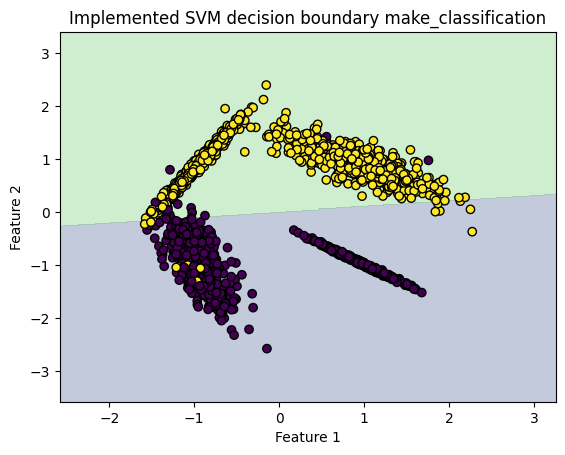

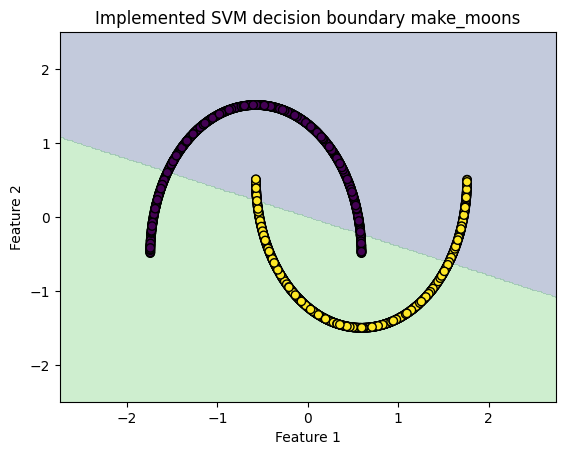

In [267]:
plot_decision_boundary(X_train_scaled, y_train_scaled, model['w'], model['b'], title="Implemented SVM decision boundary make_classification")
plot_decision_boundary(Xm_train_scaled, ym_train_scaled, model_moons['w'], model_moons['b'], title="Implemented SVM decision boundary make_moons")

# Sklearn SVM SVC

kerlen = linear

In [271]:
clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
clf.fit(X_train, y_train)
y_pred_skl = clf.predict(X_test)
y_score_skl = clf.decision_function(X_test)
accuracy_skl = accuracy_score(y_test, y_pred_skl)

clfm = make_pipeline(StandardScaler(), SVC(kernel='linear'))
clfm.fit(Xm_train, ym_train)
ym_pred_skl = clfm.predict(Xm_test)
ym_score_skl = clfm.decision_function(Xm_test)
accuracy_skl_moons = accuracy_score(ym_test, ym_pred_skl)

In [272]:
print(f"Accuracy score SVC - make_classification: {accuracy_skl}")
print(f"Accuracy score SVC - make_moons: {accuracy_skl_moons}")

Accuracy score SVC - make_classification: 0.9952076677316294
Accuracy score SVC - make_moons: 0.8945686900958466


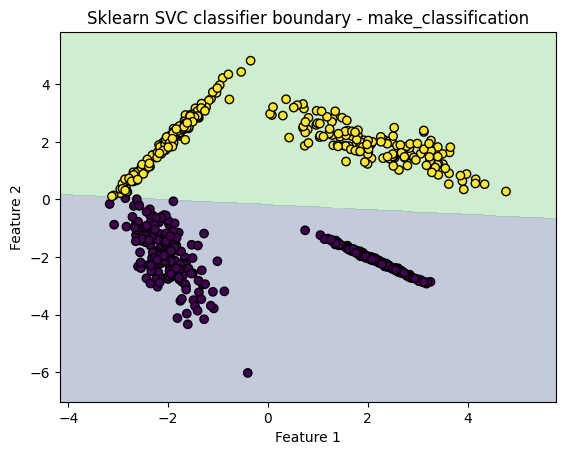

In [273]:
plot_decision_boundary_clf(X_test, y_pred_skl, clf, "Sklearn SVC classifier boundary - make_classification")

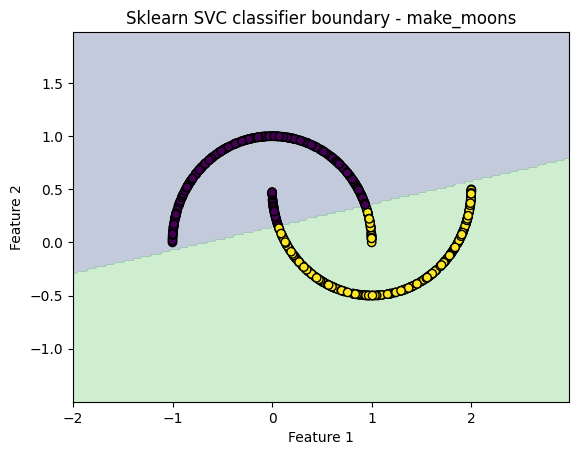

In [274]:
plot_decision_boundary_clf(Xm_test, ym_pred_skl, clfm, "Sklearn SVC classifier boundary - make_moons")

# Evaluation

In [292]:
start_time = time.time()
for _ in range(10):
    clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
    clf.fit(X_train, y_train)
sklearn_time = time.time() - start_time

start_time = time.time()
for _ in range(10):
    _ = train_impl_svm(X_train_scaled, y_train)
implemented_time = time.time() - start_time

In [293]:
print(f"Sklearn time: {sklearn_time:.6f} s")
print(f"Implemented time: {implemented_time:.6f} s")

Sklearn time: 0.050617 s
Implemented time: 587.414229 s


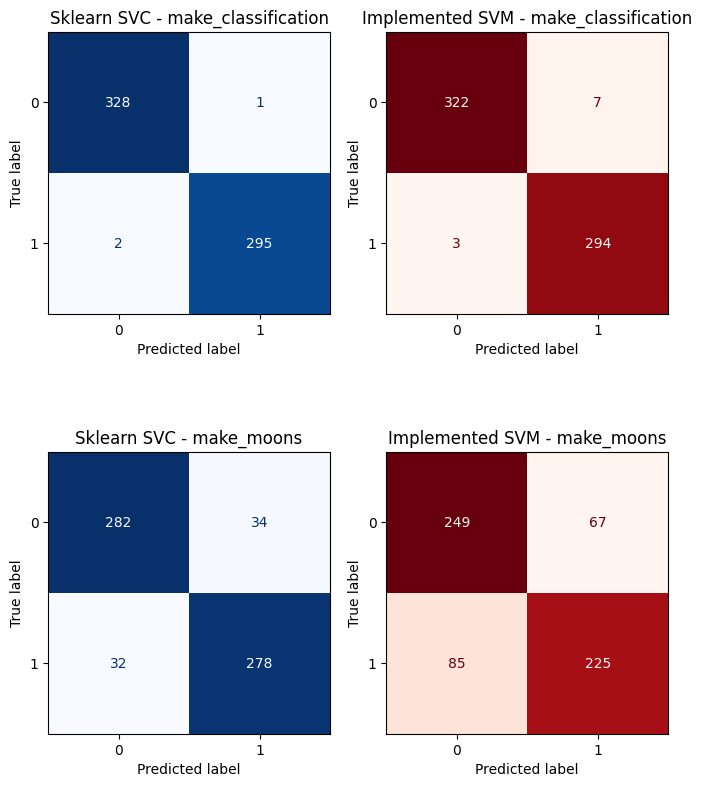

In [283]:
figure, axes = plt.subplots(2, 2, figsize=(8,10))

# make_classification dataset
cm_skl = confusion_matrix(y_test, y_pred_skl)
disp_skl = ConfusionMatrixDisplay(cm_skl)
disp_skl.plot(ax=axes[0,0], cmap='Blues', colorbar=None)
axes[0,0].set_title("Sklearn SVC - make_classification")

cm_impl = confusion_matrix(y_test_scaled, y_pred_impl)
disp_impl = ConfusionMatrixDisplay(cm_impl)
disp_impl.plot(ax=axes[0,1], cmap='Reds', colorbar=None)
axes[0,1].set_title("Implemented SVM - make_classification")

# make_moons dataset
cm_skl_m = confusion_matrix(ym_test, ym_pred_skl)
disp_skl_m = ConfusionMatrixDisplay(cm_skl_m)
disp_skl_m.plot(ax=axes[1,0], cmap='Blues', colorbar=None)
axes[1,0].set_title("Sklearn SVC - make_moons")

cm_impl_m = confusion_matrix(ym_test_scaled, y_pred_impl_moons)
disp_impl_m = ConfusionMatrixDisplay(cm_impl_m)
disp_impl_m.plot(ax=axes[1,1], cmap='Reds', colorbar=None)
axes[1,1].set_title("Implemented SVM - make_moons")

# plt.tight_layout()
plt.show()

In [284]:
name = ["Sklearn make_classification", "Sklearn moons", "Implemented make_classification", "Implemented moons"]
for i, cm in enumerate([cm_skl, cm_skl_m, cm_impl, cm_impl_m]):
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn+fp) # swoistosc
    sensitivity = tp / (tp+fn) # czulosc
    print(name[i])
    print(f"specificity: {specificity}")
    print(f"sensitivity: {sensitivity}\n")

Sklearn make_classification
specificity: 0.9969604863221885
sensitivity: 0.9932659932659933

Sklearn moons
specificity: 0.8924050632911392
sensitivity: 0.896774193548387

Implemented make_classification
specificity: 0.9787234042553191
sensitivity: 0.98989898989899

Implemented moons
specificity: 0.7879746835443038
sensitivity: 0.7258064516129032



In [285]:
# make_classification
fpr_skl, tpr_skl, _ = roc_curve(y_test, y_score_skl)
auc_skl = auc(fpr_skl, tpr_skl)

fpr_impl, tpr_impl, _ = roc_curve(y_test_scaled, y_score_impl)
auc_impl = auc(fpr_impl, tpr_impl)

# make_moons
fpr_skl_m, tpr_skl_m, _ = roc_curve(ym_test, ym_score_skl)
auc_skl_m = auc(fpr_skl_m, tpr_skl_m)

fpr_impl_m, tpr_impl_m, _ = roc_curve(ym_test_scaled, y_score_impl_moons)
auc_impl_m = auc(fpr_impl_m, tpr_impl_m)

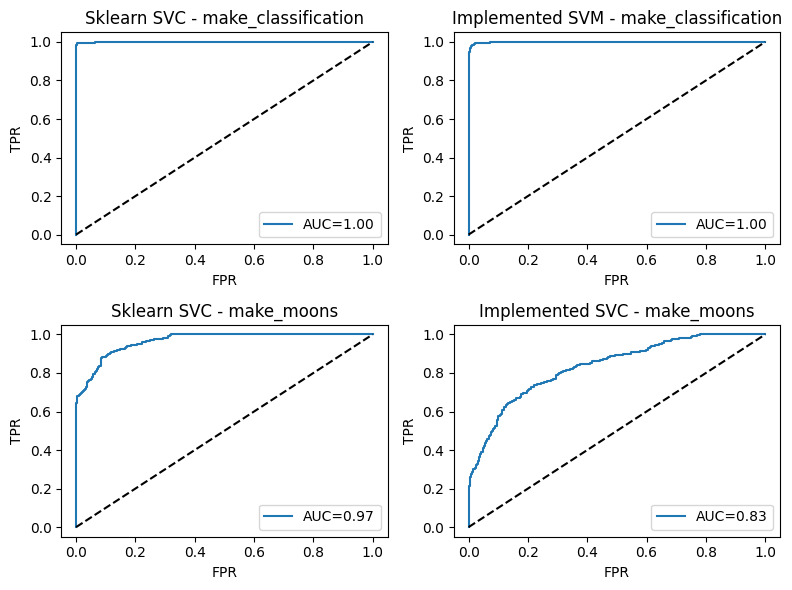

In [291]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

axes[0,0].plot(fpr_skl, tpr_skl, label=f"AUC={auc_skl:.2f}")
axes[0,0].plot([0,1],[0,1],'k--')
axes[0,0].set_title("Sklearn SVC - make_classification")
axes[0,0].set_xlabel("FPR")
axes[0,0].set_ylabel("TPR")
axes[0,0].legend(loc="lower right")

axes[0,1].plot(fpr_impl, tpr_impl, label=f"AUC={auc_impl:.2f}")
axes[0,1].plot([0,1],[0,1],'k--')
axes[0,1].set_title("Implemented SVM - make_classification")
axes[0,1].set_xlabel("FPR")
axes[0,1].set_ylabel("TPR")
axes[0,1].legend(loc="lower right")

axes[1,0].plot(fpr_skl_m, tpr_skl_m, label=f"AUC={auc_skl_m:.2f}")
axes[1,0].plot([0,1],[0,1],'k--')
axes[1,0].set_title("Sklearn SVC - make_moons")
axes[1,0].set_xlabel("FPR")
axes[1,0].set_ylabel("TPR")
axes[1,0].legend(loc="lower right")

axes[1,1].plot(fpr_impl_m, tpr_impl_m, label=f"AUC={auc_impl_m:.2f}")
axes[1,1].plot([0,1],[0,1],'k--')
axes[1,1].set_title("Implemented SVC - make_moons")
axes[1,1].set_xlabel("FPR")
axes[1,1].set_ylabel("TPR")
axes[1,1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Stellar Classification Dataset - SDSS17 

In [25]:
data = pd.read_csv('./data/star_classification.csv')
data

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [26]:
data.shape, data.columns.values

((100000, 18),
 array(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
        'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class',
        'redshift', 'plate', 'MJD', 'fiber_ID'], dtype=object))

In [27]:
# remove irrelevant columns
data = data.drop(columns=["obj_ID", # Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
                          "run_ID", # identify the specific scan
                          "rerun_ID", # specify how the image was processed
                          "cam_col", # identify the scanline within the run
                          "field_ID", # identify each field
                          "spec_obj_ID", # used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
                          "MJD", # indicate when a given piece of SDSS data was taken
                          "fiber_ID" # identifies the fiber that pointed the light at the focal plane in each observation
                          ])

In [28]:
data.shape

(100000, 10)

In [29]:
X, y = data.drop(columns=["class"]), data["class"]
X.shape, y.shape

((100000, 9), (100000,))

In [30]:
y.unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [31]:
X.isna().sum()

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
redshift    0
plate       0
dtype: int64

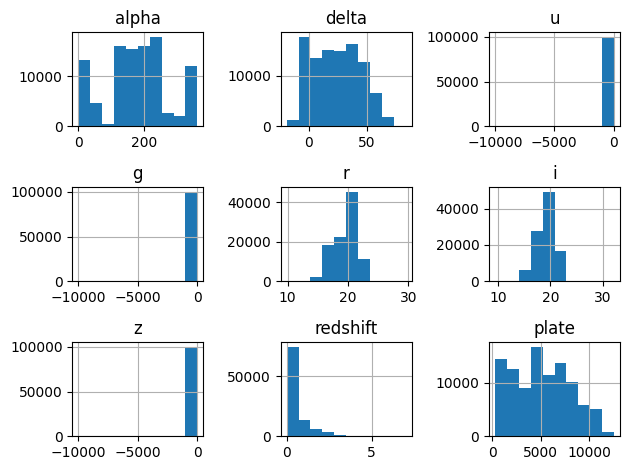

In [32]:
X.hist()
plt.tight_layout()

In [33]:
X['g'].min(), X['g'].max()

(-9999.0, 31.60224)

In [34]:
# winsorizing the data that outlies more than 1.5 IQR 
for col in ['u', 'g', 'z']:
    q1, q3 = np.quantile(X[col], [0.25,0.75]) # quantiles
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    X[col] = np.clip(X[col], lb, ub)

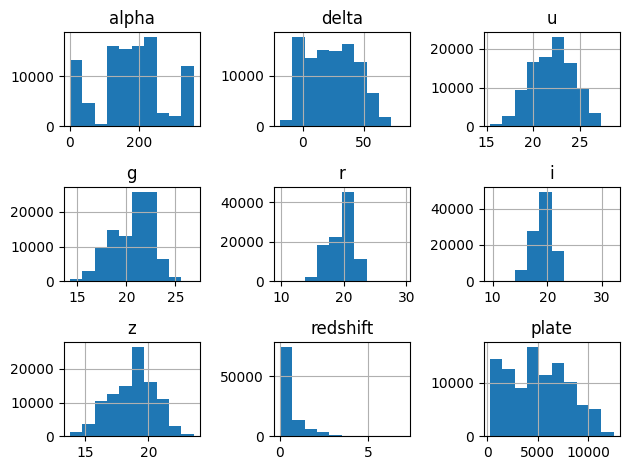

In [35]:
X.hist()
plt.tight_layout()

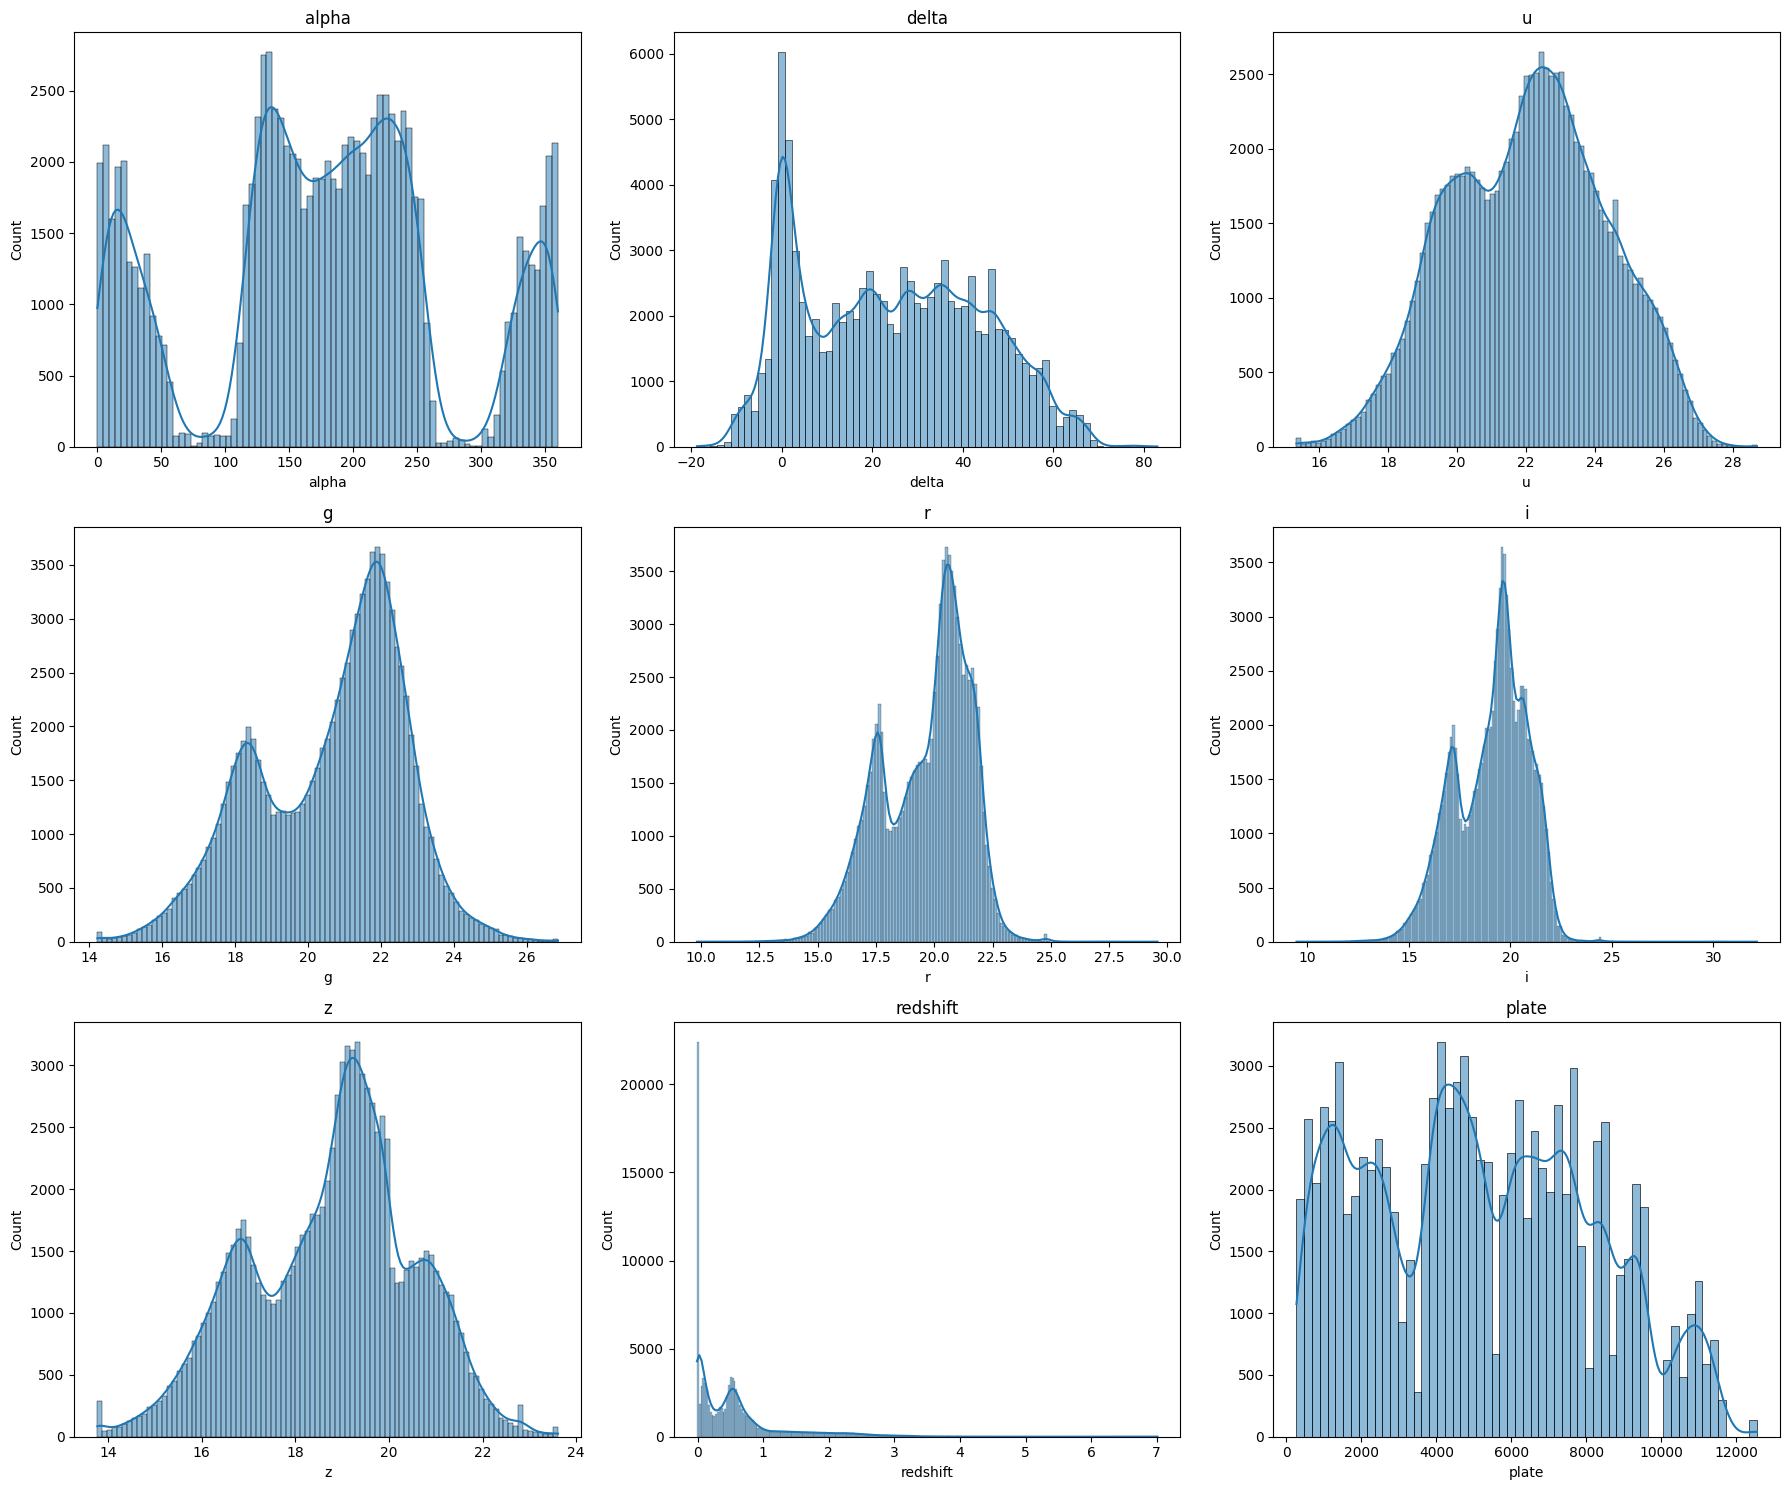

In [36]:
def plot_histograms(X):
    plt.figure(figsize=(18, 15))
    for i, col in enumerate(X.columns):
        plt.subplot(3, 3, i+1)
        sns.histplot(data=X, x=col, kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()
plot_histograms(X)

In [37]:
X['redshift'].min(), X['redshift'].max()

(-0.009970667, 7.011245)

As we can see from the distribution, we cannot standarize the data, because the data distribiution is not normal.

In [38]:
class_map = {"STAR": 0, "GALAXY": 1, "QSO": 2}
y = y.map(class_map)
y.unique()

array([1, 2, 0], dtype=int64)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=259202)

In [40]:
X_train.shape, X_test.shape

((75000, 9), (25000, 9))

In [41]:
def corr_matrix_plot(X_train, y_train):
    X_corr = X_train.copy()
    X_corr['target'] = y_train
    corr_matrix = X_corr.corr()

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f')

    plt.title('Correlation Matrix of SDSS17')
    plt.tight_layout()
    plt.show()

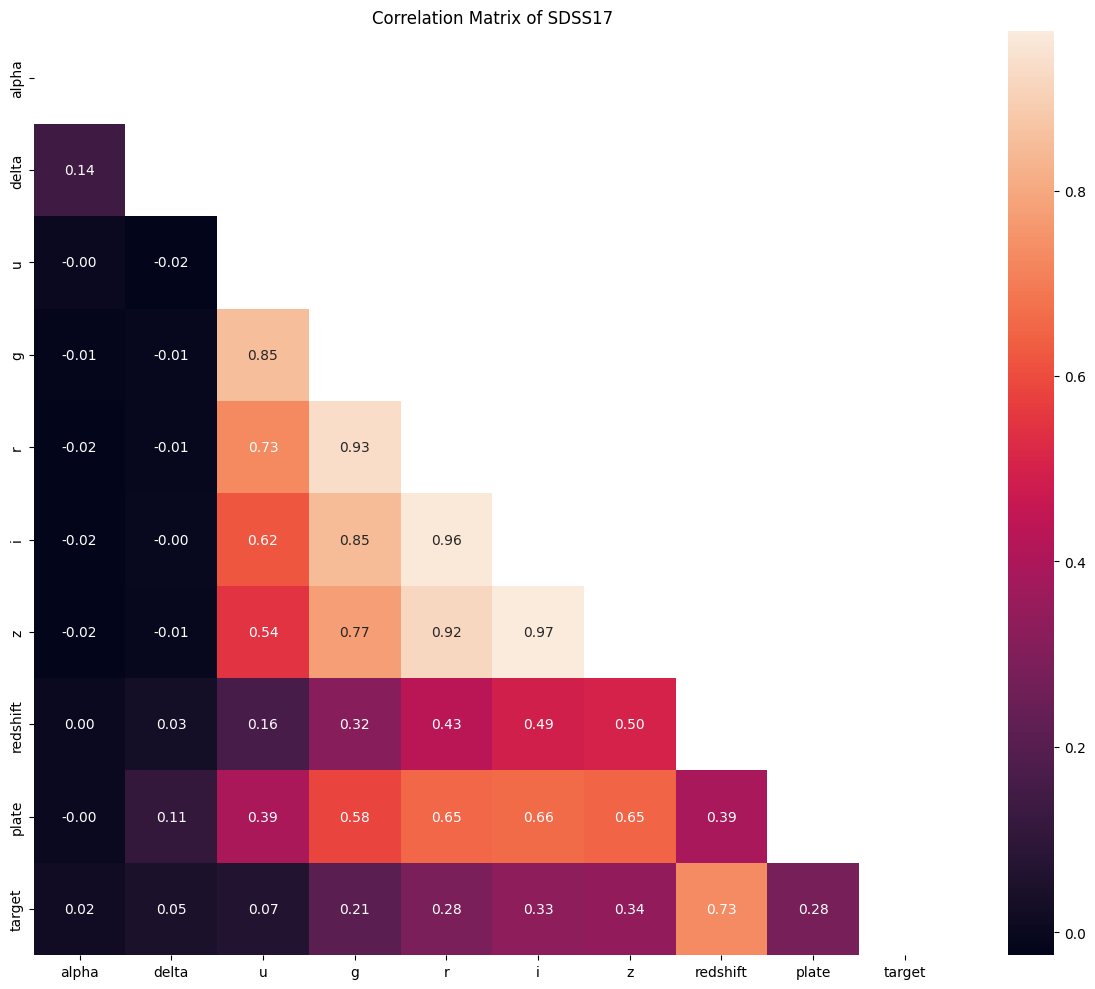

In [42]:
corr_matrix_plot(X_train, y_train)

In [43]:
# normalization
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

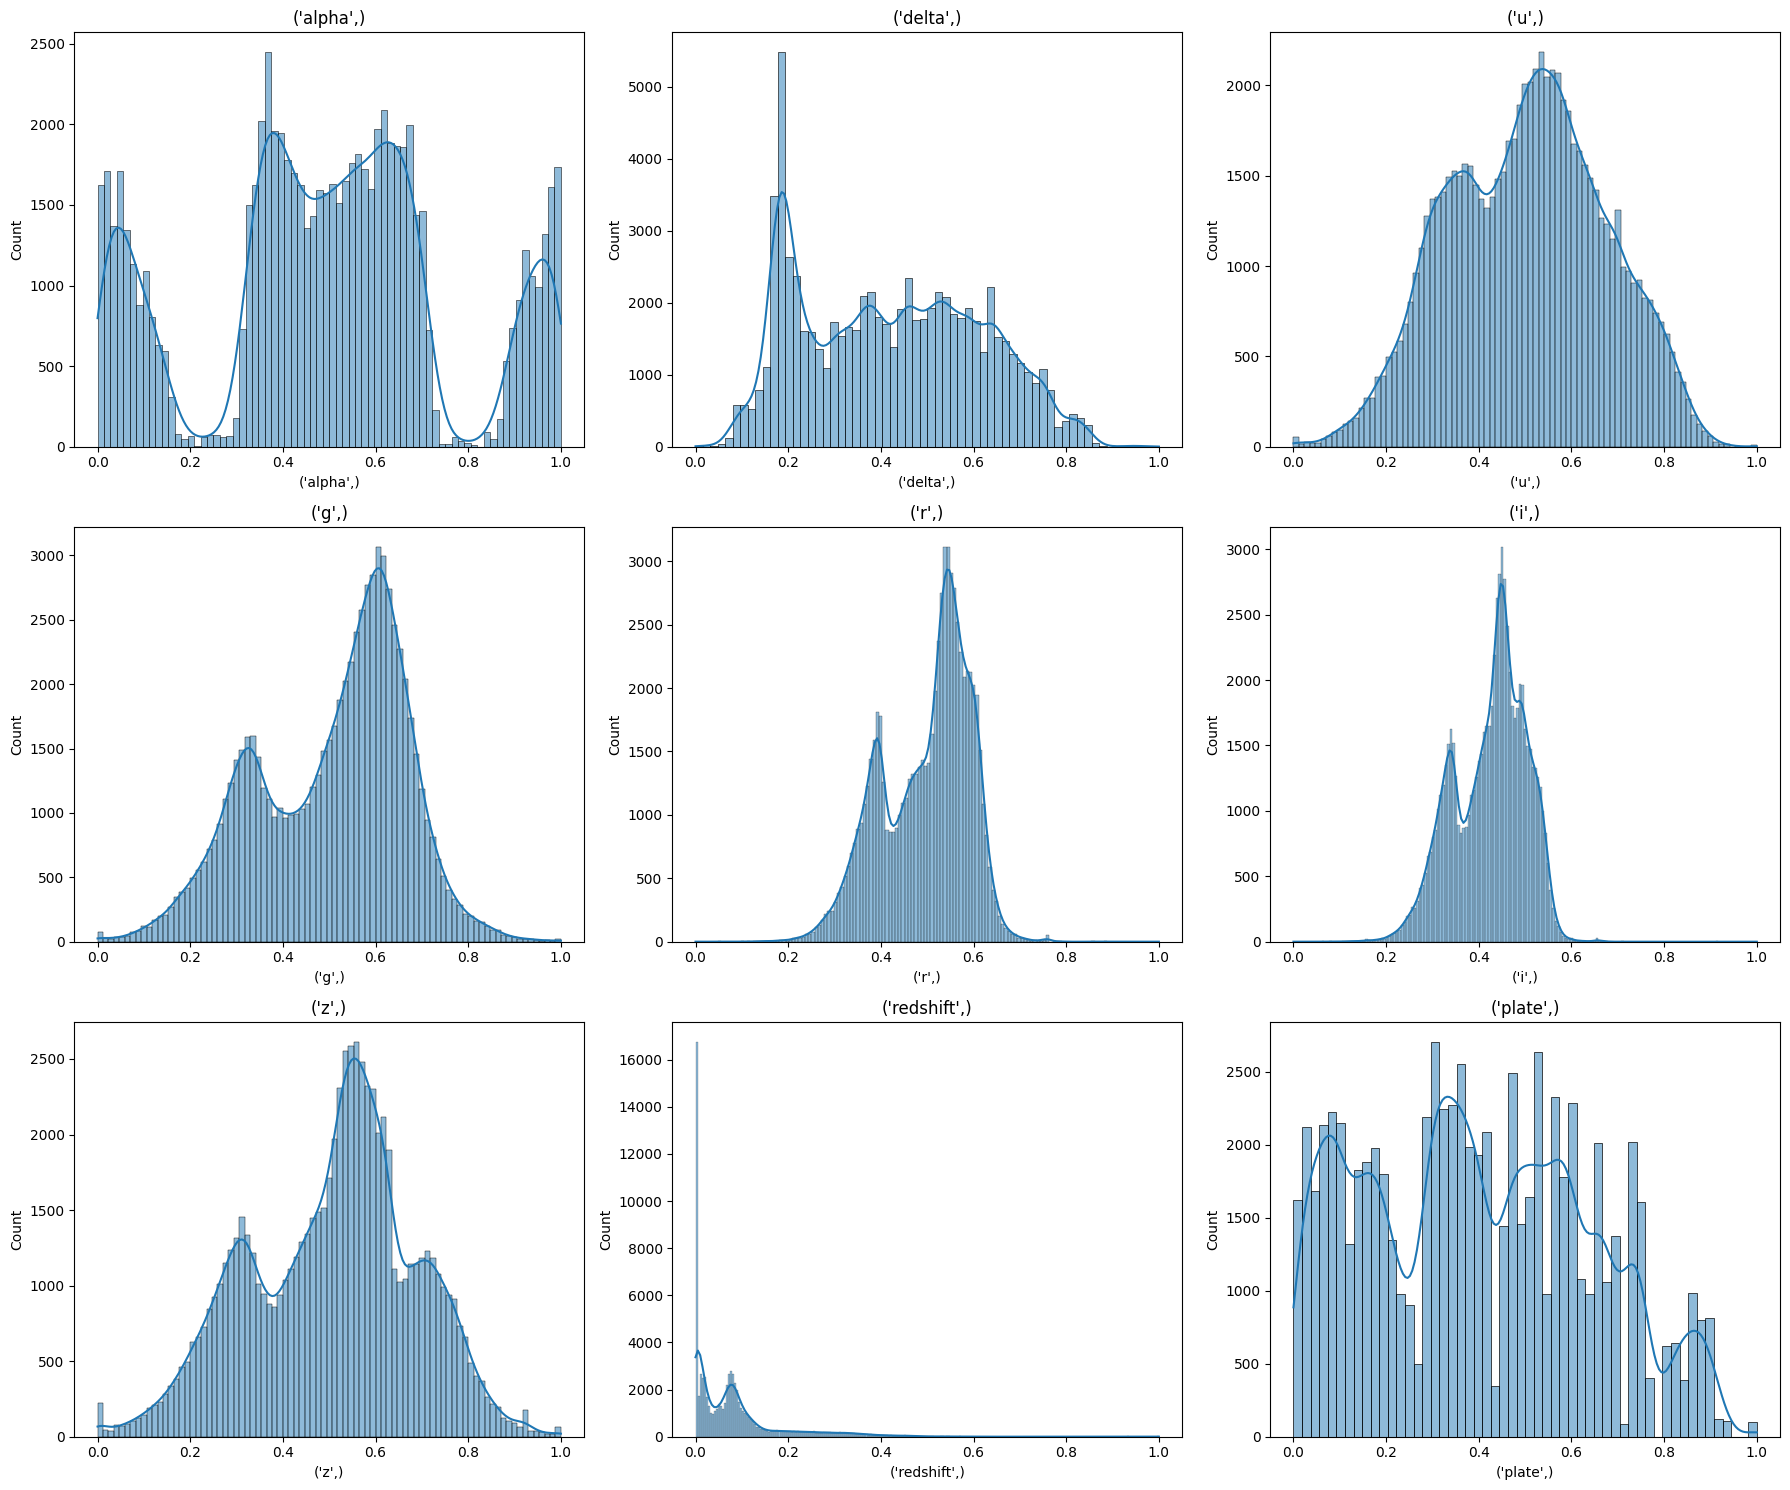

In [44]:
columns = X_train.columns.values
plot_histograms(pd.DataFrame(X_train_normalized, columns=[columns]))

Choose best hyperparameters.

 A higher C value makes the model aim for fewer misclassifications by using a smaller margin, while a lower C allows more misclassifications with a wider margin.

In [47]:
clf_linear = make_pipeline(StandardScaler(), SVC(kernel='linear'))
clf_linear.fit(X_train_normalized, y_train)
y_pred_skl_linear = clf_linear.predict(X_test_normalized)
y_score_skl_linear = clf_linear.decision_function(X_test_normalized)
accuracy_skl_linear = accuracy_score(y_test, y_pred_skl_linear)

print(f"Linear SVC accuracy: {accuracy_skl_linear}")

Linear SVC accuracy: 0.96172


In [48]:
clf_poly = make_pipeline(StandardScaler(), SVC(kernel='poly'))
clf_poly.fit(X_train_normalized, y_train)
y_pred_skl_poly = clf_poly.predict(X_test_normalized)
y_score_skl_poly = clf_poly.decision_function(X_test_normalized)
accuracy_skl_poly = accuracy_score(y_test, y_pred_skl_poly)

print(f"Poly SVC accuracy: {accuracy_skl_poly}")

Poly SVC accuracy: 0.94648


In [ ]:
# 1 hour waiting so far
# parameters = {'kernel':('linear', 'rbf', 'poly'), 'C':[0.01, 0.1, 1, 10, 100]}
# svc = svm.SVC()
# clf = GridSearchCV(svc, parameters, cv=3, n_jobs=-1, verbose=3)
# clf.fit(X_train_normalized, y_train)

In [46]:
# sorted(clf.cv_results_.keys())